In [5]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import copy
import time
import torch
import numpy as np
from torch import nn
from matplotlib import pyplot as plt
import pandas as pd

# NOE

u shape: (35000,)
th shape: (35000,)


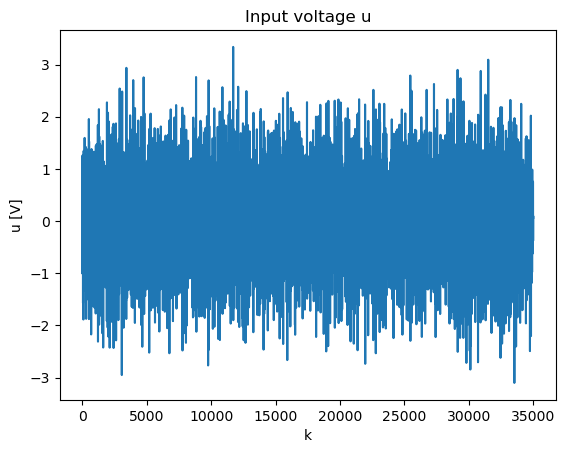

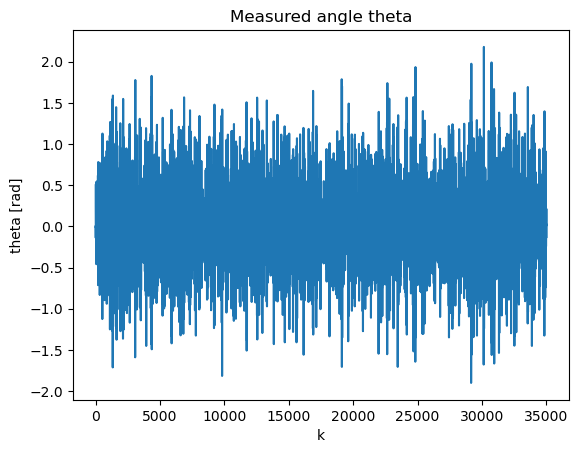

In [9]:
out = np.load("training-val-test-data.npz")

th = out["th"]   # measured disk angle
u = out["u"]     # applied input voltage

print("u shape:", u.shape)
print("th shape:", th.shape)

plt.figure()
plt.plot(u)
plt.title("Input voltage u")
plt.xlabel("k")
plt.ylabel("u [V]")
plt.show()

plt.figure()
plt.plot(th)
plt.title("Measured angle theta")
plt.xlabel("k")
plt.ylabel("theta [rad]")
plt.show()

## Split into training - validation - test

 A block split was used instead of a random split because the data are time-series samples and neighboring points are correlated. This prevents data leakage between the training and validation/test sets.

In [10]:
N = len(u)

N_train = int(0.7 * N)
N_val = int(0.15 * N)

u_train = u[:N_train]
th_train = th[:N_train]

u_val = u[N_train:N_train + N_val]
th_val = th[N_train:N_train + N_val]

u_test = u[N_train + N_val:]
th_test = th[N_train + N_val:]

print(len(u_train), len(u_val), len(u_test))

24500 5250 5250


## Normalization 

The input voltage and measured angle were normalized to zero mean and unit variance before training. The normalization constants were computed only from the training set and then applied to the validation and test sets. This avoids data leakage and improves the conditioning of the neural network training problem.

In [11]:
u_mean = u_train.mean()
u_std = u_train.std()

th_mean = th_train.mean()
th_std = th_train.std()

u_train_n = (u_train - u_mean) / u_std
u_val_n = (u_val - u_mean) / u_std
u_test_n = (u_test - u_mean) / u_std

th_train_n = (th_train - th_mean) / th_std
th_val_n = (th_val - th_mean) / th_std
th_test_n = (th_test - th_mean) / th_std

print("u mean/std:", u_mean, u_std)
print("theta mean/std:", th_mean, th_std)

u mean/std: -2.687187240524085e-05 0.8410479397424789
theta mean/std: 0.03394048474666838 0.46785269160434234


## Construction of simulation windows

For NOE training, the time series was converted into overlapping input-output windows of length `nf = 100`. Each window contains a sequence of past input voltages and the corresponding measured output angles. These windows are used to train the model on short free-run simulation rollouts instead of only one-step-ahead samples.

In [12]:
def make_OE_data(udata, ydata, nf=100):
    U = [] 
    Y = [] 
    for k in range(nf, len(udata) + 1):
        U.append(udata[k-nf:k])
        Y.append(ydata[k-nf:k])
    return np.array(U), np.array(Y)

## NOE neural network structure

A nonlinear output-error (NOE) model was implemented using a feedforward neural network as the nonlinear mapping. At each time step, the network receives delayed input voltages and delayed model outputs as regressors

In [6]:
class NOENet(nn.Module):
    def __init__(self, na=5, nb=5, hidden_size=64):
        super().__init__()

        self.na = na
        self.nb = nb
        self.n0 = max(na, nb)

        input_size = na + nb

        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, U_seq, Y_seq):
        """
        U_seq: shape (batch, sequence_length)
        Y_seq: shape (batch, sequence_length)

        We use the first n0 true outputs only for initialization.
        After that, the model recursively feeds back its own predictions.
        """

        batch_size, seq_len = U_seq.shape

        # first n0 samples are used as initial conditions
        y_generated = []
        for i in range(self.n0):
            y_generated.append(Y_seq[:, i])

        # recursive simulation
        for t in range(self.n0, seq_len):
            u_lags = U_seq[:, t-self.nb:t]
            y_lags = torch.stack(y_generated[t-self.na:t], dim=1)

            x = torch.cat([u_lags, y_lags], dim=1)

            y_next = self.net(x).squeeze(1)
            y_generated.append(y_next)

        Y_hat = torch.stack(y_generated, dim=1)

        return Y_hat

## NOE training procedure

The NOE model was trained by minimizing the mean squared simulation error over the rollout windows. The loss was computed only after the initialization period, since the first n0 samples are used as measured initial conditions and are not generated by the model. The Adam optimizer was used for parameter updates. Gradient clipping was applied to improve numerical stability during recursive simulation training. The model state with the lowest validation simulation loss was stored and restored after training.

In [8]:
def train_noe(model, train_loader, U_val_t, Y_val_t, epochs=100, lr=1e-3, weight_decay=1e-6):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=25,
        min_lr=1e-5
    )

    loss_fn = nn.MSELoss()

    train_losses = []
    val_losses = []

    best_val_loss = np.inf
    best_state = None

    for epoch in range(epochs):
        model.train()
        batch_losses = []

        for U_batch, Y_batch in train_loader:
            optimizer.zero_grad()

            Y_hat = model(U_batch, Y_batch)

            loss = loss_fn(Y_hat[:, model.n0:], Y_batch[:, model.n0:])

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            batch_losses.append(loss.item())

        train_loss = np.mean(batch_losses)

        model.eval()
        with torch.no_grad():
            Y_val_hat = model(U_val_t, Y_val_t)
            val_loss = loss_fn(Y_val_hat[:, model.n0:], Y_val_t[:, model.n0:]).item()

        # Put it here
        scheduler.step(val_loss)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())

        if epoch % 10 == 0:
            current_lr = optimizer.param_groups[0]["lr"]
            print(
                f"Epoch {epoch:4d} | "
                f"train sim loss = {train_loss:.6f} | "
                f"val sim loss = {val_loss:.6f} | "
                f"lr = {current_lr:.2e}"
            )

    model.load_state_dict(best_state)

    return train_losses, val_losses

### Full free-run NOE simulation

A full free-run simulation function was implemented to evaluate the NOE model on an entire validation sequence. The first n_0=maxn_a,n_b measured output samples were used only for initialization. After that, the model recursively predicted the output and fed each prediction back as a delayed output for the next time step. This corresponds to the simulation behavior of a nonlinear output-error model.

In [9]:
def simulate_noe_full(model, u_seq, y_seq, th_mean, th_std):
    model.eval()

    u_t = torch.tensor(u_seq, dtype=torch.float32)
    y_t = torch.tensor(y_seq, dtype=torch.float32)

    N = len(u_t)
    n0 = model.n0
    na = model.na
    nb = model.nb

    y_generated = []

    for i in range(n0):
        y_generated.append(y_t[i])

    with torch.no_grad():
        for t in range(n0, N):
            u_lags = u_t[t-nb:t].reshape(1, -1)
            y_lags = torch.stack(y_generated[t-na:t]).reshape(1, -1)

            # Safety check while debugging
            assert u_lags.shape[1] == nb, f"u_lags has {u_lags.shape[1]} values, expected {nb}"
            assert y_lags.shape[1] == na, f"y_lags has {y_lags.shape[1]} values, expected {na}"

            x = torch.cat([u_lags, y_lags], dim=1)

            assert x.shape[1] == na + nb, f"x has {x.shape[1]} values, expected {na + nb}"

            if hasattr(model, "predict_from_lags"):
                y_next = model.predict_from_lags(x).squeeze()
            else:
                y_next = model.net(x).squeeze()

            y_generated.append(y_next)

    y_hat_n = torch.stack(y_generated).numpy()

    y_hat = y_hat_n * th_std + th_mean
    y_true = y_seq * th_std + th_mean

    return y_hat, y_true

## Full validation simulation metrics

This helper runs the NOE model over the complete validation sequence and returns the RMS, RMS in degrees, NRMS and the simulated signal. This keeps the same evaluation code available for all tested configurations.

In [10]:
def evaluate_noe_full(model, u_val_n, th_val_n, th_mean, th_std):
    th_val_sim, th_val_true = simulate_noe_full(
        model,
        u_val_n,
        th_val_n,
        th_mean,
        th_std
    )

    skip = model.n0

    rms = np.sqrt(np.mean((th_val_sim[skip:] - th_val_true[skip:])**2))
    rms_deg = rms / (2*np.pi) * 360
    nrms = rms / np.std(th_val_true[skip:])

    return rms, rms_deg, nrms * 100, th_val_sim, th_val_true

## One-step-ahead prediction function

This function evaluates the model in prediction mode. The measured past outputs are used as regressors at every time step, so errors are not fed back recursively. This gives a useful comparison with the harder full simulation case.

In [11]:
def one_step_prediction_noe(model, u_seq, y_seq, th_mean, th_std):
    model.eval()

    u_t = torch.tensor(u_seq, dtype=torch.float32)
    y_t = torch.tensor(y_seq, dtype=torch.float32)

    N = len(u_t)
    n0 = model.n0
    na = model.na
    nb = model.nb

    y_pred = []

    for i in range(n0):
        y_pred.append(y_t[i])

    with torch.no_grad():
        for t in range(n0, N):
            u_lags = u_t[t-nb:t].reshape(1, -1)
            y_lags = y_t[t-na:t].reshape(1, -1)

            x = torch.cat([u_lags, y_lags], dim=1)

            if hasattr(model, "predict_from_lags"):
                y_next = model.predict_from_lags(x).squeeze()
            else:
                y_next = model.net(x).squeeze()

            y_pred.append(y_next)

    y_pred_n = torch.stack(y_pred).numpy()

    y_pred_denorm = y_pred_n * th_std + th_mean
    y_true_denorm = y_seq * th_std + th_mean

    return y_pred_denorm, y_true_denorm

## NOE hyperparameter tuning

Several NOE configurations were trained with different rollout lengths, model orders, hidden sizes and regularization values. For every configuration, both the one-step prediction error and the full simulation error were computed. A combined score was used to balance these two objectives.

In [12]:
seed = 12

noe_configs = [
    # Shorter rollout, compact memory
    {"nfuture": 50, "na": 3, "nb": 3, "hidden_size": 24, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 400},
    {"nfuture": 50, "na": 4, "nb": 3, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 400},
    {"nfuture": 50, "na": 5, "nb": 4, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 400},

    # Medium rollout, varied model orders
    {"nfuture": 60, "na": 4, "nb": 4, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 500},
    {"nfuture": 60, "na": 5, "nb": 3, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 500},
    {"nfuture": 60, "na": 6, "nb": 4, "hidden_size": 48, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 500},

    # Longer rollout, candidate stable simulators
    {"nfuture": 70, "na": 4, "nb": 4, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 500},
    {"nfuture": 70, "na": 5, "nb": 4, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 500},
    {"nfuture": 70, "na": 5, "nb": 5, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 500},
    {"nfuture": 70, "na": 6, "nb": 4, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 500},

    # Even longer rollout, lower capacity / regularization check
    {"nfuture": 80, "na": 4, "nb": 3, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 500},
    {"nfuture": 80, "na": 5, "nb": 4, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-6, "epochs": 500},
    {"nfuture": 80, "na": 6, "nb": 4, "hidden_size": 48, "lr": 3e-4, "weight_decay": 1e-5, "epochs": 500},

    # Learning-rate / regularization variants
    {"nfuture": 70, "na": 5, "nb": 4, "hidden_size": 32, "lr": 1e-4, "weight_decay": 1e-6, "epochs": 600},
    {"nfuture": 70, "na": 5, "nb": 4, "hidden_size": 32, "lr": 3e-4, "weight_decay": 1e-5, "epochs": 500},
]
noe_results = []

best_noe_rmse = np.inf
best_noe_model = None
best_noe_config = None
best_noe_losses = None
best_noe_sim = None
best_noe_true = None

for cfg in noe_configs:
    print("\n====================================")
    print("Training NOE config:", cfg)
    print("====================================")

    np.random.seed(seed)
    torch.manual_seed(seed)

    nfuture = cfg["nfuture"]

    U_train, Y_train = make_OE_data(u_train_n, th_train_n, nf=nfuture)
    U_val, Y_val = make_OE_data(u_val_n, th_val_n, nf=nfuture)

    U_train_t = torch.tensor(U_train, dtype=torch.float32)
    Y_train_t = torch.tensor(Y_train, dtype=torch.float32)
    U_val_t = torch.tensor(U_val, dtype=torch.float32)
    Y_val_t = torch.tensor(Y_val, dtype=torch.float32)

    train_dataset = TensorDataset(U_train_t, Y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

    model = NOENet(
        na=cfg["na"],
        nb=cfg["nb"],
        hidden_size=cfg["hidden_size"]
    )

    train_losses_tmp, val_losses_tmp = train_noe(
        model,
        train_loader,
        U_val_t,
        Y_val_t,
        epochs=cfg["epochs"],
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"]
    )

    rms, rms_deg, nrms_percent, th_val_sim_tmp, th_val_true_tmp = evaluate_noe_full(
        model,
        u_val_n,
        th_val_n,
        th_mean,
        th_std
    )

    # One-step prediction metric
    th_val_pred_tmp, th_val_true_pred_tmp = one_step_prediction_noe(
        model,
        u_val_n,
        th_val_n,
        th_mean,
        th_std
    )

    skip = model.n0

    pred_rms = np.sqrt(
        np.mean((th_val_pred_tmp[skip:] - th_val_true_pred_tmp[skip:])**2)
    )
    pred_rms_deg = pred_rms / (2 * np.pi) * 360
    pred_nrms_percent = pred_rms / np.std(th_val_true_pred_tmp[skip:]) * 100

    combined_score = pred_rms / 0.00665 + rms / 0.0271

    result = {
        "nfuture": cfg["nfuture"],
        "na": cfg["na"],
        "nb": cfg["nb"],
        "hidden_size": cfg["hidden_size"],
        "lr": cfg["lr"],
        "weight_decay": cfg["weight_decay"],
        "epochs": cfg["epochs"],

        "prediction_rmse_rad": pred_rms,
        "prediction_rmse_deg": pred_rms_deg,
        "prediction_nrms_percent": pred_nrms_percent,

        "simulation_rmse_rad": rms,
        "simulation_rmse_deg": rms_deg,
        "simulation_nrms_percent": nrms_percent,

        "combined_score": combined_score,

        "best_window_val_loss": np.min(val_losses_tmp),
        "best_epoch": int(np.argmin(val_losses_tmp))
    }

    noe_results.append(result)

    print("One-step prediction RMSE:", pred_rms, "rad")
    print("One-step prediction NRMS:", pred_nrms_percent, "%")
    print("Full validation simulation RMSE:", rms, "rad")
    print("Full validation simulation NRMS:", nrms_percent, "%")
    print("Combined score:", combined_score)


Training NOE config: {'nfuture': 50, 'na': 3, 'nb': 3, 'hidden_size': 24, 'lr': 0.0003, 'weight_decay': 1e-06, 'epochs': 400}
Epoch    0 | train sim loss = 0.946473 | val sim loss = 1.013393 | lr = 3.00e-04
Epoch   10 | train sim loss = 0.550910 | val sim loss = 0.612268 | lr = 3.00e-04
Epoch   20 | train sim loss = 0.024200 | val sim loss = 0.037853 | lr = 3.00e-04
Epoch   30 | train sim loss = 0.011890 | val sim loss = 0.021823 | lr = 3.00e-04
Epoch   40 | train sim loss = 0.009008 | val sim loss = 0.017018 | lr = 3.00e-04
Epoch   50 | train sim loss = 0.007880 | val sim loss = 0.015797 | lr = 3.00e-04
Epoch   60 | train sim loss = 0.007229 | val sim loss = 0.014305 | lr = 3.00e-04
Epoch   70 | train sim loss = 0.006593 | val sim loss = 0.013509 | lr = 3.00e-04
Epoch   80 | train sim loss = 0.006367 | val sim loss = 0.013350 | lr = 3.00e-04
Epoch   90 | train sim loss = 0.005917 | val sim loss = 0.013390 | lr = 3.00e-04
Epoch  100 | train sim loss = 0.005561 | val sim loss = 0.01184

In [13]:
noe_results_df = pd.DataFrame(noe_results)

# Clean results table
results_table = noe_results_df.copy()

# Sort by combined score
results_table = results_table.sort_values("combined_score").reset_index(drop=True)

# Select useful columns
cols = [
    "nfuture",
    "na",
    "nb",
    "hidden_size",
    "lr",
    "weight_decay",
    "epochs",
    "prediction_rmse_rad",
    "simulation_rmse_rad",
    "combined_score",
]

results_table = results_table[cols]

# Optional: round for readability
display_table = results_table.copy()
display_table["lr"] = display_table["lr"].map(lambda x: f"{x:.0e}")
display_table["weight_decay"] = display_table["weight_decay"].map(lambda x: f"{x:.0e}")
display_table["prediction_rmse_rad"] = display_table["prediction_rmse_rad"].round(5)
display_table["simulation_rmse_rad"] = display_table["simulation_rmse_rad"].round(5)
display_table["combined_score"] = display_table["combined_score"].round(3)

display(display_table)

# Best models according to different criteria
best_prediction = noe_results_df.loc[noe_results_df["prediction_rmse_rad"].idxmin()]
best_simulation = noe_results_df.loc[noe_results_df["simulation_rmse_rad"].idxmin()]
best_combined = noe_results_df.loc[noe_results_df["combined_score"].idxmin()]

print("\nBest one-step prediction model")
print("--------------------------------")
print(
    f"Config: nfuture={best_prediction['nfuture']}, "
    f"na={best_prediction['na']}, nb={best_prediction['nb']}, "
    f"hidden_size={best_prediction['hidden_size']}, "
    f"lr={best_prediction['lr']}, "
    f"weight_decay={best_prediction['weight_decay']}, "
    f"epochs={best_prediction['epochs']}"
)
print(f"Prediction RMSE: {best_prediction['prediction_rmse_rad']:.6f} rad")
print(f"Simulation RMSE: {best_prediction['simulation_rmse_rad']:.6f} rad")
print(f"Combined score: {best_prediction['combined_score']:.3f}")

print("\nBest full simulation model")
print("--------------------------------")
print(
    f"Config: nfuture={best_simulation['nfuture']}, "
    f"na={best_simulation['na']}, nb={best_simulation['nb']}, "
    f"hidden_size={best_simulation['hidden_size']}, "
    f"lr={best_simulation['lr']}, "
    f"weight_decay={best_simulation['weight_decay']}, "
    f"epochs={best_simulation['epochs']}"
)
print(f"Prediction RMSE: {best_simulation['prediction_rmse_rad']:.6f} rad")
print(f"Simulation RMSE: {best_simulation['simulation_rmse_rad']:.6f} rad")
print(f"Combined score: {best_simulation['combined_score']:.3f}")

print("\nBest combined model")
print("--------------------------------")
print(
    f"Config: nfuture={best_combined['nfuture']}, "
    f"na={best_combined['na']}, nb={best_combined['nb']}, "
    f"hidden_size={best_combined['hidden_size']}, "
    f"lr={best_combined['lr']}, "
    f"weight_decay={best_combined['weight_decay']}, "
    f"epochs={best_combined['epochs']}"
)
print(f"Prediction RMSE: {best_combined['prediction_rmse_rad']:.6f} rad")
print(f"Simulation RMSE: {best_combined['simulation_rmse_rad']:.6f} rad")
print(f"Combined score: {best_combined['combined_score']:.3f}")

,nfuture,na,nb,hidden_size,lr,weight_decay,epochs,prediction_rmse_rad,simulation_rmse_rad,combined_score
0,70,5,4,32,3e-04,1e-06,500,0.00624,0.02249,1.768
1,50,4,3,32,3e-04,1e-06,400,0.00430,0.03058,1.775
2,70,5,4,32,3e-04,1e-05,500,0.00623,0.02315,1.792
3,50,5,4,32,3e-04,1e-06,400,0.00634,0.02908,2.026
4,80,5,4,32,3e-04,1e-06,500,0.00676,0.02806,2.052
5,80,4,3,32,3e-04,1e-06,500,0.00579,0.03292,2.086
6,70,6,4,32,3e-04,1e-06,500,0.00748,0.02736,2.135
7,60,6,4,48,3e-04,1e-06,500,0.00690,0.02990,2.141
8,70,5,4,32,1e-04,1e-06,600,0.00756,0.02976,2.235
9,60,4,4,32,3e-04,1e-06,500,0.00512,0.04057,2.267



Best one-step prediction model
--------------------------------
Config: nfuture=50.0, na=4.0, nb=3.0, hidden_size=32.0, lr=0.0003, weight_decay=1e-06, epochs=400.0
Prediction RMSE: 0.004300 rad
Simulation RMSE: 0.030581 rad
Combined score: 1.775

Best full simulation model
--------------------------------
Config: nfuture=70.0, na=5.0, nb=4.0, hidden_size=32.0, lr=0.0003, weight_decay=1e-06, epochs=500.0
Prediction RMSE: 0.006240 rad
Simulation RMSE: 0.022490 rad
Combined score: 1.768

Best combined model
--------------------------------
Config: nfuture=70.0, na=5.0, nb=4.0, hidden_size=32.0, lr=0.0003, weight_decay=1e-06, epochs=500.0
Prediction RMSE: 0.006240 rad
Simulation RMSE: 0.022490 rad
Combined score: 1.768


## Retraining and saving the selected NOE models

The tuning cell stores the scores but not all trained model weights. Therefore, the best combined model and the best prediction model are retrained once here and saved to disk. After this, the saved `.pt` files can be loaded again without repeating the long tuning sweep.

In [16]:
import os

os.makedirs("saved_noe_models", exist_ok=True)

def train_and_evaluate_noe_choice(row, label, model_file):
    cfg = {
        "nfuture": int(row["nfuture"]),
        "na": int(row["na"]),
        "nb": int(row["nb"]),
        "hidden_size": int(row["hidden_size"]),
        "lr": float(row["lr"]),
        "weight_decay": float(row["weight_decay"]),
        "epochs": int(row["epochs"]),
    }

    print("\n====================================")
    print(label)
    print("Config:", cfg)
    print("====================================")

    np.random.seed(seed)
    torch.manual_seed(seed)

    U_train_choice, Y_train_choice = make_OE_data(
        u_train_n,
        th_train_n,
        nf=cfg["nfuture"]
    )
    U_val_choice, Y_val_choice = make_OE_data(
        u_val_n,
        th_val_n,
        nf=cfg["nfuture"]
    )

    U_train_choice_t = torch.tensor(U_train_choice, dtype=torch.float32)
    Y_train_choice_t = torch.tensor(Y_train_choice, dtype=torch.float32)
    U_val_choice_t = torch.tensor(U_val_choice, dtype=torch.float32)
    Y_val_choice_t = torch.tensor(Y_val_choice, dtype=torch.float32)

    train_dataset_choice = TensorDataset(U_train_choice_t, Y_train_choice_t)
    train_loader_choice = DataLoader(
        train_dataset_choice,
        batch_size=256,
        shuffle=True
    )

    model = NOENet(
        na=cfg["na"],
        nb=cfg["nb"],
        hidden_size=cfg["hidden_size"]
    )

    train_losses, val_losses = train_noe(
        model,
        train_loader_choice,
        U_val_choice_t,
        Y_val_choice_t,
        epochs=cfg["epochs"],
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"]
    )

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "config": cfg,
            "label": label,
            "train_losses": train_losses,
            "val_losses": val_losses,
        },
        model_file
    )

    print("Saved model to:", model_file)

    th_val_pred, th_val_true_pred = one_step_prediction_noe(
        model,
        u_val_n,
        th_val_n,
        th_mean,
        th_std
    )

    th_val_sim, th_val_true = simulate_noe_full(
        model,
        u_val_n,
        th_val_n,
        th_mean,
        th_std
    )

    skip = model.n0

    pred_rms = np.sqrt(np.mean((th_val_pred[skip:] - th_val_true_pred[skip:])**2))
    pred_rms_deg = pred_rms / (2*np.pi) * 360
    pred_nrms = pred_rms / np.std(th_val_true_pred[skip:])

    sim_rms = np.sqrt(np.mean((th_val_sim[skip:] - th_val_true[skip:])**2))
    sim_rms_deg = sim_rms / (2*np.pi) * 360
    sim_nrms = sim_rms / np.std(th_val_true[skip:])

    combined_score = pred_rms / 0.00665 + sim_rms / 0.0271

    print("One-step prediction RMS:", pred_rms, "rad")
    print("One-step prediction RMS:", pred_rms_deg, "deg")
    print("One-step prediction NRMS:", pred_nrms * 100, "%")
    print("Full simulation RMS:", sim_rms, "rad")
    print("Full simulation RMS:", sim_rms_deg, "deg")
    print("Full simulation NRMS:", sim_nrms * 100, "%")
    print("Combined score:", combined_score)

    return {
        "label": label,
        "config": cfg,
        "model_file": model_file,
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "th_val_pred": th_val_pred,
        "th_val_true_pred": th_val_true_pred,
        "th_val_sim": th_val_sim,
        "th_val_true": th_val_true,
        "skip": skip,
        "pred_rms": pred_rms,
        "sim_rms": sim_rms,
        "combined_score": combined_score,
    }

In [17]:
best_combined_eval = train_and_evaluate_noe_choice(
    best_combined,
    "Best combined NOE model",
    "saved_noe_models/best_combined_noe.pt"
)

best_prediction_eval = train_and_evaluate_noe_choice(
    best_prediction,
    "Best one-step prediction NOE model",
    "saved_noe_models/best_prediction_noe.pt"
)


Best combined NOE model
Config: {'nfuture': 70, 'na': 5, 'nb': 4, 'hidden_size': 32, 'lr': 0.0003, 'weight_decay': 1e-06, 'epochs': 500}
Epoch    0 | train sim loss = 0.747286 | val sim loss = 0.770009 | lr = 3.00e-04
Epoch   10 | train sim loss = 0.017891 | val sim loss = 0.043369 | lr = 3.00e-04
Epoch   20 | train sim loss = 0.008309 | val sim loss = 0.026032 | lr = 3.00e-04
Epoch   30 | train sim loss = 0.004090 | val sim loss = 0.015093 | lr = 3.00e-04
Epoch   40 | train sim loss = 0.002877 | val sim loss = 0.010500 | lr = 3.00e-04
Epoch   50 | train sim loss = 0.002309 | val sim loss = 0.007844 | lr = 3.00e-04
Epoch   60 | train sim loss = 0.002059 | val sim loss = 0.006790 | lr = 3.00e-04
Epoch   70 | train sim loss = 0.001918 | val sim loss = 0.006460 | lr = 3.00e-04
Epoch   80 | train sim loss = 0.001779 | val sim loss = 0.006335 | lr = 3.00e-04
Epoch   90 | train sim loss = 0.001690 | val sim loss = 0.005728 | lr = 3.00e-04
Epoch  100 | train sim loss = 0.001593 | val sim los

### Selected NOE model results

The best combined model is the main final NOE choice because it balances prediction and full simulation performance. Its full simulation RMS is about 0.0225 rad, while the best prediction model has a lower one-step RMS of about 0.00430 rad but a higher full simulation RMS. This shows the trade-off between one-step prediction and free-run simulation.

## Training and validation loss comparison

The next plot compares the simulation training loss and validation loss for the two selected NOE models. The loss is shown on a logarithmic scale because it decreases strongly during training.

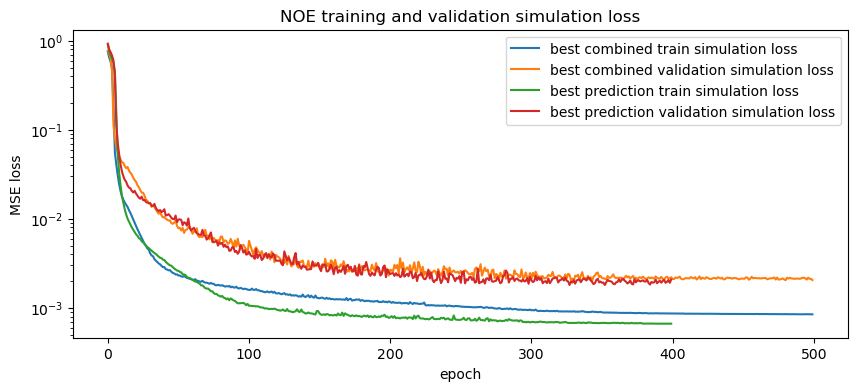

In [18]:
plt.figure(figsize=(10, 4))

plt.plot(
    best_combined_eval["train_losses"],
    label="best combined train simulation loss"
)
plt.plot(
    best_combined_eval["val_losses"],
    label="best combined validation simulation loss"
)

plt.plot(
    best_prediction_eval["train_losses"],
    label="best prediction train simulation loss"
)
plt.plot(
    best_prediction_eval["val_losses"],
    label="best prediction validation simulation loss"
)

plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.title("NOE training and validation simulation loss")
plt.legend()
plt.show()

## Short validation rollout for the best combined NOE model

This evaluates one validation window using the best combined model. The first samples are used for initialization and the rest of the window is generated recursively by the model.

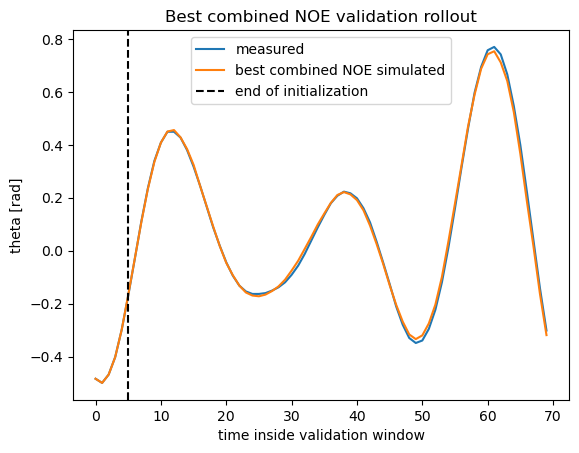

Best combined validation rollout RMS: 0.013439581 rad
Best combined validation rollout RMS: 0.7700312581590063 deg
Best combined validation rollout NRMS: 4.585207253694534 %


In [20]:
final_noe_model = best_combined_eval["model"]
final_noe_model.eval()

cfg = best_combined_eval["config"]
nfuture = cfg["nfuture"]

U_val_combined, Y_val_combined = make_OE_data(
    u_val_n,
    th_val_n,
    nf=nfuture
)

U_val_combined_t = torch.tensor(U_val_combined, dtype=torch.float32)
Y_val_combined_t = torch.tensor(Y_val_combined, dtype=torch.float32)

with torch.no_grad():
    Y_val_hat = final_noe_model(
        U_val_combined_t[:1],
        Y_val_combined_t[:1]
    ).numpy()

Y_true = Y_val_combined_t[:1].numpy()

# denormalize
Y_hat_denorm = Y_val_hat[0] * th_std + th_mean
Y_true_denorm = Y_true[0] * th_std + th_mean

plt.figure()
plt.plot(Y_true_denorm, label="measured")
plt.plot(Y_hat_denorm, label="best combined NOE simulated")
plt.axvline(
    final_noe_model.n0,
    color="black",
    linestyle="--",
    label="end of initialization"
)
plt.xlabel("time inside validation window")
plt.ylabel("theta [rad]")
plt.title("Best combined NOE validation rollout")
plt.legend()
plt.show()

rms_window = np.sqrt(
    np.mean(
        (Y_hat_denorm[final_noe_model.n0:] - Y_true_denorm[final_noe_model.n0:])**2
    )
)
rms_window_deg = rms_window / (2*np.pi) * 360
nrms_window = rms_window / np.std(Y_true_denorm[final_noe_model.n0:])

print("Best combined validation rollout RMS:", rms_window, "rad")
print("Best combined validation rollout RMS:", rms_window_deg, "deg")
print("Best combined validation rollout NRMS:", nrms_window * 100, "%")

### Short rollout result

For this validation window, the best combined model gives an RMS of about 0.0134 rad, or 0.77 degrees. The error stays small over the short rollout, which shows that the model follows the measured angle well after initialization.

## Full validation simulation for the best combined NOE model

The model is now simulated over the full validation sequence. This is the most important NOE test because the model must keep using its own previous predictions.

Best combined full validation simulation RMS: 0.02248972629555716 rad
Best combined full validation simulation RMS: 1.2885663991398126 deg
Best combined full validation simulation NRMS: 4.569201734806911 %


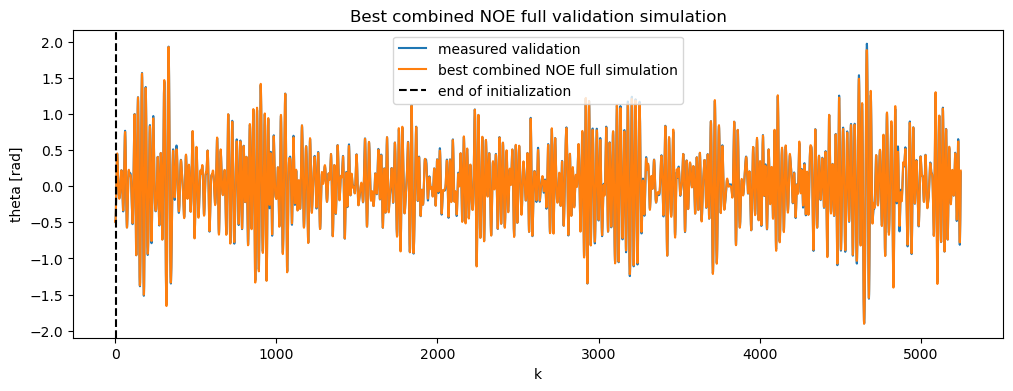

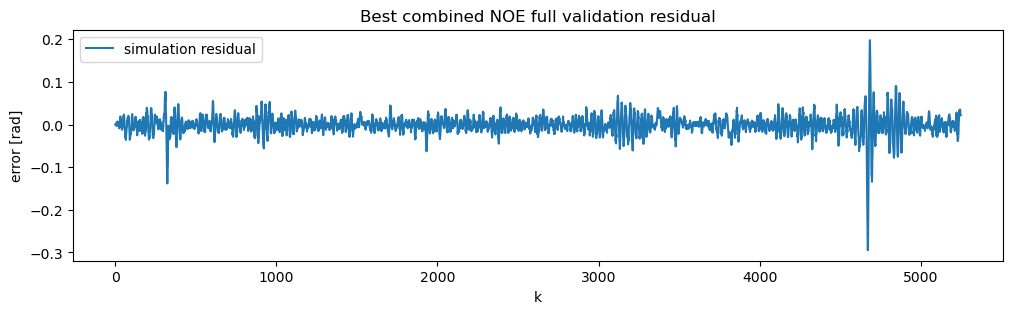

In [21]:
final_noe_model = best_combined_eval["model"]
final_noe_model.eval()

th_val_sim, th_val_true = simulate_noe_full(
    final_noe_model,
    u_val_n,
    th_val_n,
    th_mean,
    th_std
)

skip = final_noe_model.n0

rms = np.sqrt(np.mean((th_val_sim[skip:] - th_val_true[skip:])**2))
rms_deg = rms / (2*np.pi) * 360
nrms = rms / np.std(th_val_true[skip:])

print("Best combined full validation simulation RMS:", rms, "rad")
print("Best combined full validation simulation RMS:", rms_deg, "deg")
print("Best combined full validation simulation NRMS:", nrms * 100, "%")

plt.figure(figsize=(12, 4))
plt.plot(th_val_true, label="measured validation")
plt.plot(th_val_sim, label="best combined NOE full simulation")
plt.axvline(skip, color="black", linestyle="--", label="end of initialization")
plt.xlabel("k")
plt.ylabel("theta [rad]")
plt.title("Best combined NOE full validation simulation")
plt.legend()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(th_val_sim - th_val_true, label="simulation residual")
plt.xlabel("k")
plt.ylabel("error [rad]")
plt.title("Best combined NOE full validation residual")
plt.legend()
plt.show()

### Full simulation result

The full validation simulation RMS is about 0.0225 rad, or 1.29 degrees. The NRMS is about 4.57%. This is the result used to judge how well the NOE model works in free-run simulation.

## One-step prediction for the best combined NOE model

Finally, the same best combined model is evaluated in one-step-ahead prediction mode. This is easier than full simulation because the measured output history is used at each time step.

Best combined validation one-step prediction RMS: 0.0062395140388512085 rad
Best combined validation one-step prediction RMS: 0.35749782063880065 deg
Best combined validation one-step prediction NRMS: 1.2676720915142075 %


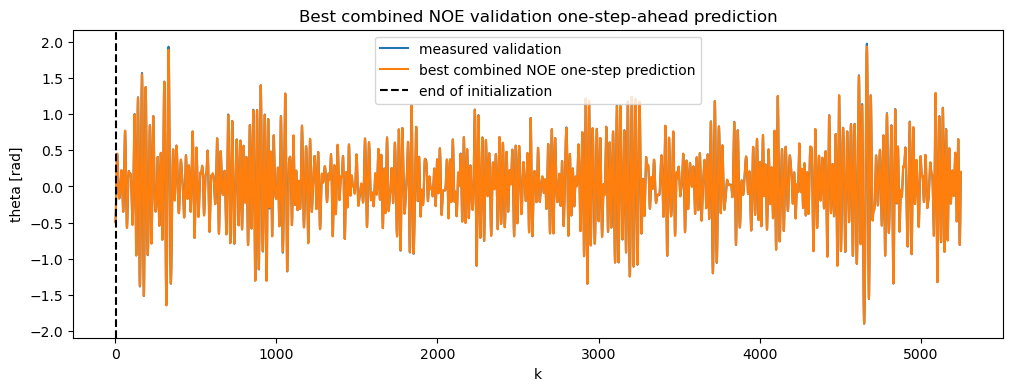

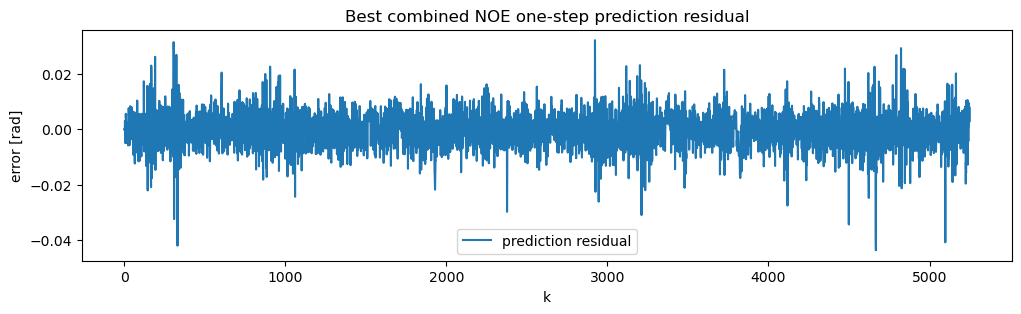

In [22]:
final_noe_model = best_combined_eval["model"]
final_noe_model.eval()

th_val_pred, th_val_true_pred = one_step_prediction_noe(
    final_noe_model,
    u_val_n,
    th_val_n,
    th_mean,
    th_std
)

skip = final_noe_model.n0

pred_rms = np.sqrt(np.mean((th_val_pred[skip:] - th_val_true_pred[skip:])**2))
pred_rms_deg = pred_rms / (2*np.pi) * 360
pred_nrms = pred_rms / np.std(th_val_true_pred[skip:])

print("Best combined validation one-step prediction RMS:", pred_rms, "rad")
print("Best combined validation one-step prediction RMS:", pred_rms_deg, "deg")
print("Best combined validation one-step prediction NRMS:", pred_nrms * 100, "%")

plt.figure(figsize=(12, 4))
plt.plot(th_val_true_pred, label="measured validation")
plt.plot(th_val_pred, label="best combined NOE one-step prediction")
plt.axvline(skip, color="black", linestyle="--", label="end of initialization")
plt.xlabel("k")
plt.ylabel("theta [rad]")
plt.title("Best combined NOE validation one-step-ahead prediction")
plt.legend()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(th_val_pred - th_val_true_pred, label="prediction residual")
plt.xlabel("k")
plt.ylabel("error [rad]")
plt.title("Best combined NOE one-step prediction residual")
plt.legend()
plt.show()

### One-step prediction result

The best combined model reaches a one-step prediction RMS of about 0.00624 rad, or 0.36 degrees. This is lower than the full simulation error, as expected, because the prediction test does not accumulate errors recursively.

# RNN

## RNN sequence data

For the RNN model, the normalized input-output time series was converted into overlapping sequences of length `nfuture_rnn`. This follows the sequence construction used in the lecture exercise. Each training sample contains an input voltage sequence and the corresponding measured angle sequence.

In [13]:
nfuture_rnn = 150

U_train_rnn, Y_train_rnn = make_OE_data(u_train_n, th_train_n, nf=nfuture_rnn)
U_val_rnn, Y_val_rnn = make_OE_data(u_val_n, th_val_n, nf=nfuture_rnn)

U_train_rnn_t = torch.tensor(U_train_rnn, dtype=torch.float64)
Y_train_rnn_t = torch.tensor(Y_train_rnn, dtype=torch.float64)

U_val_rnn_t = torch.tensor(U_val_rnn, dtype=torch.float64)
Y_val_rnn_t = torch.tensor(Y_val_rnn, dtype=torch.float64)

print(U_train_rnn_t.shape, Y_train_rnn_t.shape)
print(U_val_rnn_t.shape, Y_val_rnn_t.shape)

torch.Size([24351, 150]) torch.Size([24351, 150])
torch.Size([5101, 150]) torch.Size([5101, 150])


## Simple RNN model

The RNN model follows the structure used in the lecture exercise. It consists of two neural networks: `h2h`, which updates the hidden state, and `h2o`, which maps the current hidden state and input to the output. The model equations are

h_{k+1} = \text{h2h}(h_k,u_k),

hat{\theta}_k = \text{h2o}(h_k,u_k).

The hidden state is initialized to zero at the start of each sequence.

In [14]:
class simple_RNN(nn.Module):
    def __init__(self, hidden_size):
        super(simple_RNN, self).__init__()

        self.hidden_size = hidden_size
        self.input_size = 1
        self.output_size = 1

        net = lambda n_in, n_out: nn.Sequential(
            nn.Linear(n_in, 40),
            nn.Sigmoid(),
            nn.Linear(40, n_out)
        ).double()

        self.h2h = net(self.hidden_size + self.input_size, self.hidden_size)
        self.h2o = net(self.hidden_size + self.input_size, self.output_size)

    def forward(self, inputs):
        # inputs shape = (N_batch, N_time)

        N_batch = inputs.shape[0]
        N_time = inputs.shape[1]

        hidden = torch.zeros(
            N_batch,
            self.hidden_size,
            dtype=torch.float64
        )

        outputs = []

        for k in range(N_time):
            uk = inputs[:, k:k+1]

            h_and_u = torch.cat((hidden, uk), dim=1)

            yk = self.h2o(h_and_u)[:, 0]

            hidden = self.h2h(h_and_u)

            outputs.append(yk)

        outputs = torch.stack(outputs, dim=1)

        return outputs

## RNN training

The RNN was trained using mini-batch optimization with the Adam optimizer, following the lecture exercise. The loss was computed after a burn-in period of `n_burn` samples, because the hidden state is initialized at zero and needs a few samples to encode information about the system state. The training and validation losses are reported as normalized sequence RMSE values.

In [15]:
n_burn = 30
batch_size = 64
hidden_size = 8
epochs = 150

model_rnn = simple_RNN(hidden_size=hidden_size)
optimizer = torch.optim.Adam(model_rnn.parameters(), lr=3e-4)

train_losses_rnn = []
val_losses_rnn = []

ids = np.arange(len(U_train_rnn_t), dtype=int)

for epoch in range(epochs):
    np.random.shuffle(ids)

    for i in range(0, len(U_train_rnn_t), batch_size):
        ids_now = ids[i:i+batch_size]

        U_batch = U_train_rnn_t[ids_now]
        Y_batch = Y_train_rnn_t[ids_now]

        Y_pred = model_rnn(inputs=U_batch)

        loss = torch.mean((Y_pred[:, n_burn:] - Y_batch[:, n_burn:])**2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        train_loss = torch.mean((model_rnn(inputs=U_train_rnn_t)[:, n_burn:] - Y_train_rnn_t[:, n_burn:])**2).sqrt()
        val_loss = torch.mean((model_rnn(inputs=U_val_rnn_t)[:, n_burn:] - Y_val_rnn_t[:, n_burn:])**2).sqrt()

    train_losses_rnn.append(train_loss.item())
    val_losses_rnn.append(val_loss.item())

    print(f"epoch={epoch}, Validation Loss={val_loss.item():.2%}, Train Loss={train_loss.item():.2%}")

KeyboardInterrupt: 

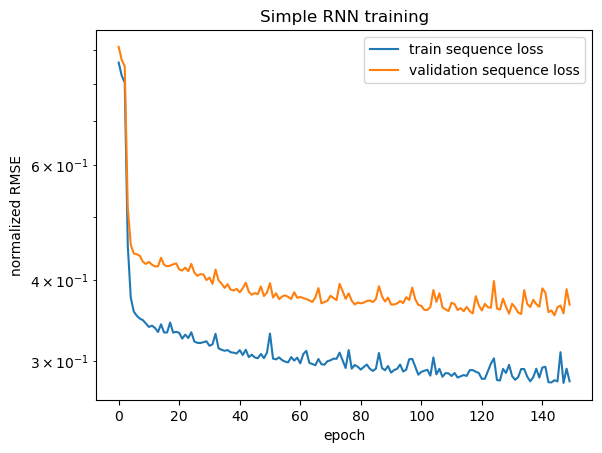

In [28]:
plt.figure()
plt.plot(train_losses_rnn, label="train sequence loss")
plt.plot(val_losses_rnn, label="validation sequence loss")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("normalized RMSE")
plt.title("Simple RNN training")
plt.legend()
plt.show()

## Full validation simulation with the RNN

The trained RNN was evaluated on the full validation input sequence. The hidden state was initialized to zero and then updated recursively using the input sequence. The first `n_burn` samples were skipped when computing the RMSE, because they correspond to the initial transient of the hidden state. The simulated output was compared with the measured validation angle.

RNN full validation simulation RMS: 0.1375135835486628 rad
RNN full validation simulation RMS: 7.8789479630580095 deg
RNN full validation simulation NRMS: 27.88693317190259 %


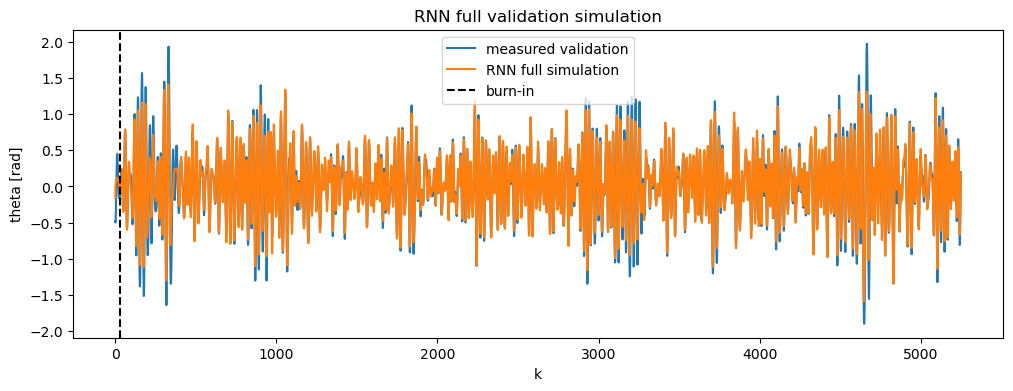

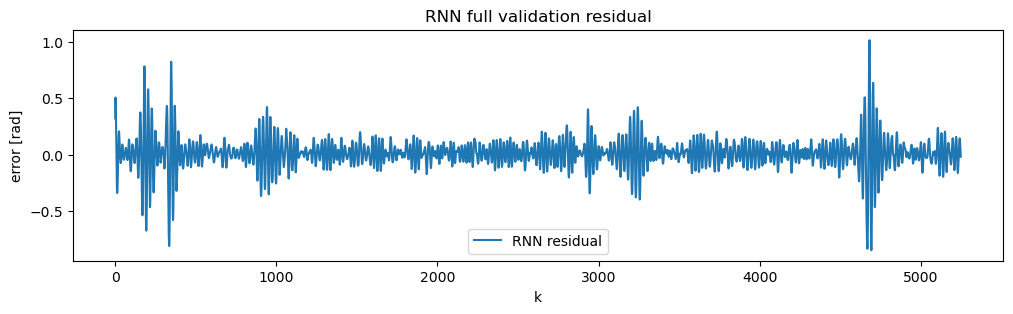

In [29]:
model_rnn.eval()

with torch.no_grad():
    U_val_full_t = torch.tensor(u_val_n[None, :], dtype=torch.float64)
    th_val_sim_rnn_n = model_rnn(U_val_full_t).numpy()[0]

th_val_sim_rnn = th_val_sim_rnn_n * th_std + th_mean
th_val_true = th_val_n * th_std + th_mean

skip = n_burn

rms_rnn = np.sqrt(np.mean((th_val_sim_rnn[skip:] - th_val_true[skip:])**2))
rms_deg_rnn = rms_rnn / (2*np.pi) * 360
nrms_rnn = rms_rnn / np.std(th_val_true[skip:])

print("RNN full validation simulation RMS:", rms_rnn, "rad")
print("RNN full validation simulation RMS:", rms_deg_rnn, "deg")
print("RNN full validation simulation NRMS:", nrms_rnn * 100, "%")

plt.figure(figsize=(12,4))
plt.plot(th_val_true, label="measured validation")
plt.plot(th_val_sim_rnn, label="RNN full simulation")
plt.axvline(skip, color="black", linestyle="--", label="burn-in")
plt.xlabel("k")
plt.ylabel("theta [rad]")
plt.title("RNN full validation simulation")
plt.legend()
plt.show()

plt.figure(figsize=(12,3))
plt.plot(th_val_sim_rnn - th_val_true, label="RNN residual")
plt.xlabel("k")
plt.ylabel("error [rad]")
plt.title("RNN full validation residual")
plt.legend()
plt.show()

## Encoder RNN sequence data

For the encoder RNN, each training sample contains three parts: a future input sequence \(U_k\), the corresponding output sequence \(Y_k\), and a history vector containing past inputs and past outputs. The history vector is used by the encoder network to estimate the initial hidden state of the RNN.

In [16]:
def make_OE_init_state_data(udata, ydata, nf=100, n_encode=20):
    U = [] 
    Y = [] 
    hist = [] 

    for k in range(nf + n_encode, len(udata) + 1):
        U.append(udata[k-nf:k])
        Y.append(ydata[k-nf:k])

        u_past = udata[k-nf-n_encode:k-nf]
        y_past = ydata[k-nf-n_encode:k-nf]

        hist.append(np.concatenate((u_past, y_past)))

    return np.array(hist), np.array(U), np.array(Y)

## Encoder history length

The encoder history length was set to \(n_e=20\). Therefore, the encoder input contains 20 past input samples and 20 past output samples. This provides the RNN with information about the initial state before the simulated sequence starts.

In [17]:
nfuture_rnn = 100
n_encode = 50

convert = lambda x: [torch.tensor(xi, dtype=torch.float64) for xi in x]

hist_train_rnn, U_train_rnn, Y_train_rnn = convert(
    make_OE_init_state_data(
        u_train_n,
        th_train_n,
        nf=nfuture_rnn,
        n_encode=n_encode
    )
)

hist_val_rnn, U_val_rnn, Y_val_rnn = convert(
    make_OE_init_state_data(
        u_val_n,
        th_val_n,
        nf=nfuture_rnn,
        n_encode=n_encode
    )
)

print("hist_train:", hist_train_rnn.shape)
print("U_train:", U_train_rnn.shape)
print("Y_train:", Y_train_rnn.shape)

print("hist_val:", hist_val_rnn.shape)
print("U_val:", U_val_rnn.shape)
print("Y_val:", Y_val_rnn.shape)

hist_train: torch.Size([24351, 100])
U_train: torch.Size([24351, 100])
Y_train: torch.Size([24351, 100])
hist_val: torch.Size([5101, 100])
U_val: torch.Size([5101, 100])
Y_val: torch.Size([5101, 100])


## Encoder RNN model

In [18]:
class simple_encoder_RNN(nn.Module):
    def __init__(self, hidden_size, n_encoder=20):
        super(simple_encoder_RNN, self).__init__()

        self.hidden_size = hidden_size
        self.input_size = 1
        self.output_size = 1
        self.n_encoder = n_encoder

        net = lambda n_in, n_out: nn.Sequential(
            nn.Linear(n_in, 40),
            nn.Sigmoid(),
            nn.Linear(40, n_out)
        ).double()

        self.h2h = net(self.input_size + hidden_size, self.hidden_size)
        self.h2o = net(self.input_size + hidden_size, self.output_size)
        self.encoder = net(n_encoder * 2, hidden_size)

    def forward(self, inputs, hist):
        hidden = self.encoder(hist)

        outputs = []

        for i in range(inputs.shape[1]):
            input_i = inputs[:, i]
            combined = torch.cat((hidden, input_i[:, None]), dim=1)

            outputs.append(self.h2o(combined)[:, 0])

            hidden = self.h2h(combined)

        return torch.stack(outputs, dim=1)

In [19]:
def one_step_prediction_encoder_rnn(model, u_seq, y_seq, n_encode, th_mean, th_std):
    """
    One-step-ahead prediction for the encoder RNN.

    At each time step, the encoder uses measured past input-output data
    to initialize the hidden state, and then predicts only the next output.
    """

    model.eval()

    y_pred_n = []

    # Copy first n_encode samples only to keep the same signal length
    for i in range(n_encode):
        y_pred_n.append(y_seq[i])

    with torch.no_grad():
        for k in range(n_encode, len(u_seq)):
            u_hist = u_seq[k-n_encode:k]
            y_hist = y_seq[k-n_encode:k]

            hist = np.concatenate((u_hist, y_hist))[None, :]
            u_now = u_seq[k:k+1][None, :]

            hist_t = torch.tensor(hist, dtype=torch.float64)
            u_now_t = torch.tensor(u_now, dtype=torch.float64)

            y_now_pred = model(inputs=u_now_t, hist=hist_t).numpy()[0, 0]

            y_pred_n.append(y_now_pred)

    y_pred_n = np.array(y_pred_n)

    y_pred = y_pred_n * th_std + th_mean
    y_true = y_seq * th_std + th_mean

    return y_pred, y_true

### Full validation simulation with encoder RNN

For the full validation simulation, the first \(n_e\) measured input-output samples were used as encoder history to estimate the initial hidden state. After this initialization, the RNN simulated the remaining validation sequence using only the input signal and the recurrent hidden state dynamics.

In [20]:
def simulate_encoder_rnn_full(model, u_seq, y_seq, n_encode, th_mean, th_std):
    """
    Full validation simulation for encoder RNN.

    Uses the first n_encode input-output samples as history to initialize hidden state.
    Then simulates the rest of the sequence.
    """

    model.eval()

    u_hist = u_seq[:n_encode]
    y_hist = y_seq[:n_encode]

    hist = np.concatenate((u_hist, y_hist))[None, :]
    u_future = u_seq[n_encode:][None, :]

    hist_t = torch.tensor(hist, dtype=torch.float64)
    u_future_t = torch.tensor(u_future, dtype=torch.float64)

    with torch.no_grad():
        y_future_pred_n = model(inputs=u_future_t, hist=hist_t).numpy()[0]

    y_pred_n = np.concatenate((y_seq[:n_encode], y_future_pred_n))

    y_pred = y_pred_n * th_std + th_mean
    y_true = y_seq * th_std + th_mean

    return y_pred, y_true

## Encoder RNN training

The encoder RNN was trained using the Adam optimizer and mean squared sequence error. In contrast to the simple RNN, no burn-in period is required, because the initial hidden state is estimated directly from the past input-output history using the encoder network.

In [ ]:
encoder_rnn_configs = [
    {"n_encode": 20, "hidden_size": 8,  "epochs": 300, "lr": 1e-3},
    {"n_encode": 20, "hidden_size": 16, "epochs": 300, "lr": 1e-3},
    {"n_encode": 20, "hidden_size": 32, "epochs": 300, "lr": 1e-3},
    {"n_encode": 20, "hidden_size": 48, "epochs": 300, "lr": 1e-3},
]

encoder_rnn_results = []

best_encoder_score = np.inf
best_encoder_rnn = None
best_encoder_config = None
best_encoder_losses = None
best_encoder_n_encode = None
best_encoder_sim = None
best_encoder_true = None

nfuture_rnn = 150
batch_size = 128

for cfg in encoder_rnn_configs:
    print("\n====================================")
    print("Training Encoder RNN config:", cfg)
    print("====================================")

    n_encode = cfg["n_encode"]
    hidden_size = cfg["hidden_size"]
    epochs = cfg["epochs"]
    lr = cfg["lr"]

    convert = lambda x: [torch.tensor(xi, dtype=torch.float64) for xi in x]

    hist_train_rnn, U_train_rnn, Y_train_rnn = convert(
        make_OE_init_state_data(
            u_train_n,
            th_train_n,
            nf=nfuture_rnn,
            n_encode=n_encode
        )
    )

    hist_val_rnn, U_val_rnn, Y_val_rnn = convert(
        make_OE_init_state_data(
            u_val_n,
            th_val_n,
            nf=nfuture_rnn,
            n_encode=n_encode
        )
    )

    model_encoder_rnn = simple_encoder_RNN(
        hidden_size=hidden_size,
        n_encoder=n_encode
    )

    optimizer = torch.optim.Adam(model_encoder_rnn.parameters(), lr=lr)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=15, min_lr=1e-5)
    best_val_loss_cfg = np.inf
    best_state_cfg = None

    early_stop_patience = 40
    epochs_no_improve = 0

    train_losses_encoder_rnn = []
    val_losses_encoder_rnn = []

    ids = np.arange(len(U_train_rnn), dtype=int)

    for epoch in range(epochs):
        np.random.shuffle(ids)

        model_encoder_rnn.train()

        for i in range(0, len(U_train_rnn), batch_size):
            ids_now = ids[i:i+batch_size]

            Uin = U_train_rnn[ids_now]
            histin = hist_train_rnn[ids_now]
            Y_real = Y_train_rnn[ids_now]

            Y_predict = model_encoder_rnn(inputs=Uin, hist=histin)

            residual = Y_real - Y_predict
            loss = torch.mean(residual**2)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model_encoder_rnn.parameters(),
                max_norm=1.0
            )
            optimizer.step()

        model_encoder_rnn.eval()
        with torch.no_grad():
            Y_val_pred = model_encoder_rnn(inputs=U_val_rnn, hist=hist_val_rnn)
            Y_train_pred = model_encoder_rnn(inputs=U_train_rnn, hist=hist_train_rnn)

            loss_val = torch.mean((Y_val_pred - Y_val_rnn)**2)**0.5
            loss_train = torch.mean((Y_train_pred - Y_train_rnn)**2)**0.5

        scheduler.step(loss_val)
        if loss_val < best_val_loss_cfg:
            best_val_loss_cfg = loss_val
            best_state_cfg = copy.deepcopy(model_encoder_rnn.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= early_stop_patience:
            print(f"Early stopping at epoch {epoch}")
            break

        train_losses_encoder_rnn.append(loss_train.item())
        val_losses_encoder_rnn.append(loss_val.item())

        print(
            f"epoch={epoch}, "
            f"Validation Loss={loss_val.item():.2%}, "
            f"Train Loss={loss_train.item():.2%}"
        )

    model_encoder_rnn.load_state_dict(best_state_cfg)

    # Full validation simulation for this config
    th_val_sim_encoder_rnn, th_val_true_encoder_rnn = simulate_encoder_rnn_full(
        model_encoder_rnn,
        u_val_n,
        th_val_n,
        n_encode,
        th_mean,
        th_std
    )

    skip = n_encode

    sim_rms_encoder_rnn = np.sqrt(
        np.mean((th_val_sim_encoder_rnn[skip:] - th_val_true_encoder_rnn[skip:])**2)
    )
    sim_rms_deg_encoder_rnn = sim_rms_encoder_rnn / (2*np.pi) * 360
    sim_nrms_encoder_rnn = sim_rms_encoder_rnn / np.std(th_val_true_encoder_rnn[skip:])

    # One-step-ahead prediction for this config
    th_val_pred_encoder_rnn, th_val_true_pred_encoder_rnn = one_step_prediction_encoder_rnn(
        model_encoder_rnn,
        u_val_n,
        th_val_n,
        n_encode,
        th_mean,
        th_std
    )

    pred_rms_encoder_rnn = np.sqrt(
        np.mean((th_val_pred_encoder_rnn[skip:] - th_val_true_pred_encoder_rnn[skip:])**2)
    )
    pred_rms_deg_encoder_rnn = pred_rms_encoder_rnn / (2*np.pi) * 360
    pred_nrms_encoder_rnn = pred_rms_encoder_rnn / np.std(
        th_val_true_pred_encoder_rnn[skip:]
    )

    combined_score = pred_rms_encoder_rnn / 0.00665 + sim_rms_encoder_rnn / 0.0271

    print("Encoder RNN one-step prediction RMS:", pred_rms_encoder_rnn, "rad")
    print("Encoder RNN one-step prediction RMS:", pred_rms_deg_encoder_rnn, "deg")
    print("Encoder RNN one-step prediction NRMS:", pred_nrms_encoder_rnn * 100, "%")

    print("Encoder RNN full validation simulation RMS:", sim_rms_encoder_rnn, "rad")
    print("Encoder RNN full validation simulation RMS:", sim_rms_deg_encoder_rnn, "deg")
    print("Encoder RNN full validation simulation NRMS:", sim_nrms_encoder_rnn * 100, "%")

    print("Encoder RNN combined score:", combined_score)

    result = {
        "n_encode": n_encode,
        "hidden_size": hidden_size,
        "epochs": epochs,
        "lr": lr,

        "prediction_rmse_rad": pred_rms_encoder_rnn,
        "prediction_rmse_deg": pred_rms_deg_encoder_rnn,
        "prediction_nrms_percent": pred_nrms_encoder_rnn * 100,

        "simulation_rmse_rad": sim_rms_encoder_rnn,
        "simulation_rmse_deg": sim_rms_deg_encoder_rnn,
        "simulation_nrms_percent": sim_nrms_encoder_rnn * 100,

        "combined_score": combined_score,

        "best_window_val_loss": np.min(val_losses_encoder_rnn),
        "best_epoch": int(np.argmin(val_losses_encoder_rnn))
    }

    encoder_rnn_results.append(result)

    if combined_score < best_encoder_score:
        best_encoder_score = combined_score
        best_encoder_rnn = copy.deepcopy(model_encoder_rnn)
        best_encoder_config = copy.deepcopy(cfg)
        best_encoder_losses = (
            train_losses_encoder_rnn,
            val_losses_encoder_rnn
        )
        best_encoder_n_encode = n_encode
        best_encoder_sim = th_val_sim_encoder_rnn
        best_encoder_true = th_val_true_encoder_rnn

encoder_rnn_results_df = pd.DataFrame(encoder_rnn_results)
encoder_rnn_results_df.sort_values("combined_score")


Training Encoder RNN config: {'n_encode': 20, 'hidden_size': 8, 'epochs': 200, 'lr': 0.001}
epoch=0, Validation Loss=86.56%, Train Loss=81.90%
epoch=1, Validation Loss=84.24%, Train Loss=79.52%
epoch=2, Validation Loss=65.78%, Train Loss=61.96%
epoch=3, Validation Loss=45.15%, Train Loss=38.16%
epoch=4, Validation Loss=42.46%, Train Loss=34.82%
epoch=5, Validation Loss=39.95%, Train Loss=32.22%
epoch=6, Validation Loss=41.53%, Train Loss=34.43%
epoch=7, Validation Loss=39.27%, Train Loss=32.23%
epoch=8, Validation Loss=39.47%, Train Loss=31.79%
epoch=9, Validation Loss=40.68%, Train Loss=33.33%
epoch=10, Validation Loss=38.91%, Train Loss=30.77%
epoch=11, Validation Loss=36.88%, Train Loss=29.07%
epoch=12, Validation Loss=39.72%, Train Loss=32.61%
epoch=13, Validation Loss=37.65%, Train Loss=29.81%
epoch=14, Validation Loss=37.00%, Train Loss=28.76%
epoch=15, Validation Loss=39.71%, Train Loss=32.05%
epoch=16, Validation Loss=37.18%, Train Loss=29.32%
epoch=17, Validation Loss=35.76%,

,n_encode,hidden_size,epochs,lr,prediction_rmse_rad,prediction_rmse_deg,prediction_nrms_percent,simulation_rmse_rad,simulation_rmse_deg,simulation_nrms_percent,combined_score,best_window_val_loss,best_epoch
0,20,8,200,0.001,0.019844,1.136963,4.027600,0.049588,2.841194,10.064700,4.813845,0.101025,188
1,50,8,200,0.001,0.022953,1.315125,4.647093,0.054443,3.119334,11.022400,5.460572,0.110131,182
2,100,8,200,0.001,0.030919,1.771543,6.245457,0.062926,3.605381,12.710531,6.971497,0.127504,185


In [1]:
print("Best Encoder RNN configuration:")
print(best_encoder_config)

print("\nBest Encoder RNN combined score:", best_encoder_score)

encoder_rnn_results_df.sort_values("combined_score")

Best Encoder RNN configuration:


NameError: name 'best_encoder_config' is not defined

In [2]:
plt.figure()
plt.plot(train_losses_encoder_rnn, label="train sequence loss")
plt.plot(val_losses_encoder_rnn, label="validation sequence loss")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("normalized RMSE")
plt.title("Encoder RNN training")
plt.legend()
plt.show()

NameError: name 'plt' is not defined

Encoder RNN full validation simulation RMS: 0.07261718945692414 rad
Encoder RNN full validation simulation RMS: 4.160658475983651 deg
Encoder RNN full validation simulation NRMS: 14.698427309290002 %


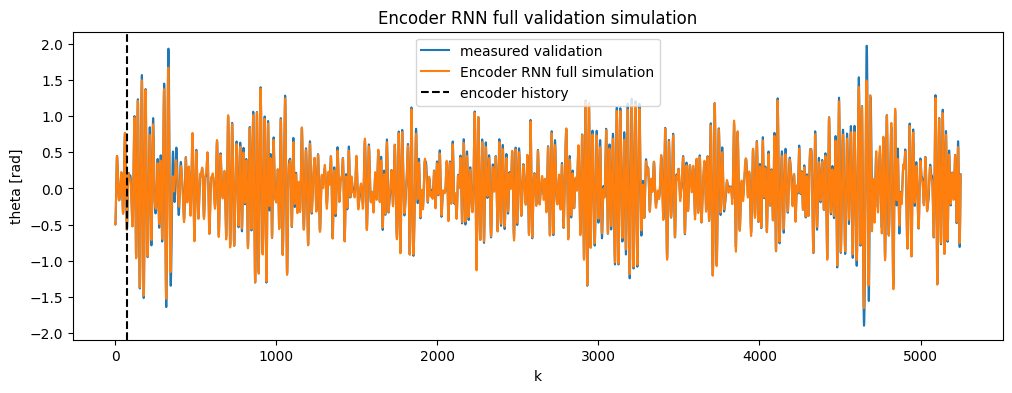

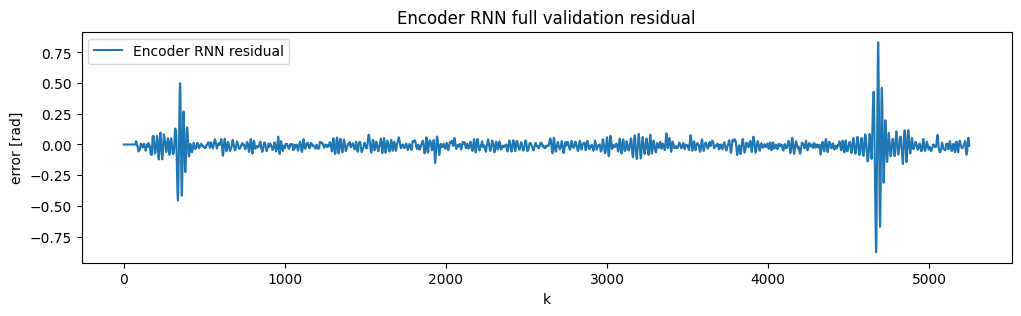

In [41]:
th_val_sim_encoder_rnn, th_val_true_encoder_rnn = simulate_encoder_rnn_full(
    model_encoder_rnn,
    u_val_n,
    th_val_n,
    n_encode,
    th_mean,
    th_std
)

skip = n_encode

rms_encoder_rnn = np.sqrt(
    np.mean((th_val_sim_encoder_rnn[skip:] - th_val_true_encoder_rnn[skip:])**2)
)

rms_deg_encoder_rnn = rms_encoder_rnn / (2*np.pi) * 360
nrms_encoder_rnn = rms_encoder_rnn / np.std(th_val_true_encoder_rnn[skip:])

print("Encoder RNN full validation simulation RMS:", rms_encoder_rnn, "rad")
print("Encoder RNN full validation simulation RMS:", rms_deg_encoder_rnn, "deg")
print("Encoder RNN full validation simulation NRMS:", nrms_encoder_rnn * 100, "%")

plt.figure(figsize=(12,4))
plt.plot(th_val_true_encoder_rnn, label="measured validation")
plt.plot(th_val_sim_encoder_rnn, label="Encoder RNN full simulation")
plt.axvline(skip, color="black", linestyle="--", label="encoder history")
plt.xlabel("k")
plt.ylabel("theta [rad]")
plt.title("Encoder RNN full validation simulation")
plt.legend()
plt.show()

plt.figure(figsize=(12,3))
plt.plot(th_val_sim_encoder_rnn - th_val_true_encoder_rnn, label="Encoder RNN residual")
plt.xlabel("k")
plt.ylabel("error [rad]")
plt.title("Encoder RNN full validation residual")
plt.legend()
plt.show()

## RNN tuning summary

As a recurrent neural-network baseline, a simple RNN was first trained using the structure from the exercise set. In this model, the hidden state was initialized to zero at the beginning of each sequence. The simple RNN achieved a full validation simulation RMSE of 0.1436 rad. This was better than the linear benchmark, but still significantly worse than the NOE model. The main limitation is that the zero initial hidden state does not contain information about the actual initial state of the system.

To improve this, an encoder RNN was tested. In this architecture, the initial hidden state is not fixed to zero, but is estimated from a past input-output history:


h_0 = encoder(u_{\text{past}}, y_{\text{past}})


This improved the full validation simulation RMSE from 0.1436 rad to 0.0909 rad for \(n_{encode}=20\) and hidden size 15. This confirmed that estimating the initial hidden state from past data is important for recurrent models in system identification.

The encoder history length and hidden state dimension were then tuned. Increasing the encoder history from \(n_{encode}=20\) to \(n_{encode}=50\) improved the result further, because the encoder had more information about the recent system behavior. With \(n_{encode}=50\) and hidden size 15, the RMSE decreased to 0.0835 rad. Increasing the hidden size to 30 with the same encoder history gave the best RNN result, with RMSE 0.0772 rad, corresponding to 4.42 degrees and NRMS 15.63%.

Additional experiments showed that further increasing the number of epochs from 50 to 100 did not improve the full validation simulation performance. Although the training loss continued to decrease, the full validation RMSE increased to 0.1039 rad, indicating overfitting or unstable long-horizon recurrent behavior. A larger encoder history of \(n_{encode}=100\) also worsened the performance, giving RMSE 0.2045 rad. This suggests that too large an encoder input dimension can make the initial state estimation problem harder for this relatively simple encoder network.

Overall, the encoder RNN clearly improved over the simple RNN, showing that hidden-state initialization is important. However, the best RNN result remained worse than the final NOE model. This indicates that, for this dataset and this simple RNN architecture, the explicit delayed-output structure of the NOE model was more effective than the learned hidden-state representation of the RNN.

## Encoder RNN one-step-ahead prediction

The best encoder RNN model was also evaluated in one-step-ahead prediction mode. For each validation time step, the encoder used the measured past input-output history to estimate the initial hidden state, and the RNN then predicted only the next output sample. This is easier than full free-run simulation, because the model is re-initialized from measured past data at every time step and prediction errors do not accumulate over the full validation trajectory.

In [42]:
final_encoder_rnn = model_encoder_rnn   
final_n_encode = 50                     

In [43]:
def one_step_prediction_encoder_rnn(model, u_seq, y_seq, n_encode, th_mean, th_std):
    """
    One-step-ahead prediction for the encoder RNN.

    At each time step, the encoder uses measured past input-output data
    to initialize the hidden state, and then predicts only the next output.
    """

    model.eval()

    y_pred_n = []

    # Copy first n_encode samples only to keep the same signal length
    for i in range(n_encode):
        y_pred_n.append(y_seq[i])

    with torch.no_grad():
        for k in range(n_encode, len(u_seq)):
            u_hist = u_seq[k-n_encode:k]
            y_hist = y_seq[k-n_encode:k]

            hist = np.concatenate((u_hist, y_hist))[None, :]
            u_now = u_seq[k:k+1][None, :]

            hist_t = torch.tensor(hist, dtype=torch.float64)
            u_now_t = torch.tensor(u_now, dtype=torch.float64)

            y_now_pred = model(inputs=u_now_t, hist=hist_t).numpy()[0, 0]

            y_pred_n.append(y_now_pred)

    y_pred_n = np.array(y_pred_n)

    y_pred = y_pred_n * th_std + th_mean
    y_true = y_seq * th_std + th_mean

    return y_pred, y_true

In [45]:
final_n_encode = final_encoder_rnn.n_encoder

th_val_pred_encoder_rnn, th_val_true_encoder_rnn = one_step_prediction_encoder_rnn(
    final_encoder_rnn,
    u_val_n,
    th_val_n,
    final_n_encode,
    th_mean,
    th_std
)

skip = final_n_encode

rms_pred_encoder_rnn = np.sqrt(
    np.mean((th_val_pred_encoder_rnn[skip:] - th_val_true_encoder_rnn[skip:])**2)
)

rms_deg_pred_encoder_rnn = rms_pred_encoder_rnn / (2*np.pi) * 360
nrms_pred_encoder_rnn = rms_pred_encoder_rnn / np.std(th_val_true_encoder_rnn[skip:])

print("Encoder RNN one-step prediction RMS:", rms_pred_encoder_rnn, "rad")
print("Encoder RNN one-step prediction RMS:", rms_deg_pred_encoder_rnn, "deg")
print("Encoder RNN one-step prediction NRMS:", nrms_pred_encoder_rnn * 100, "%")

Encoder RNN one-step prediction RMS: 0.050933706779025714 rad
Encoder RNN one-step prediction RMS: 2.9182864333950436 deg
Encoder RNN one-step prediction NRMS: 10.309478957847722 %


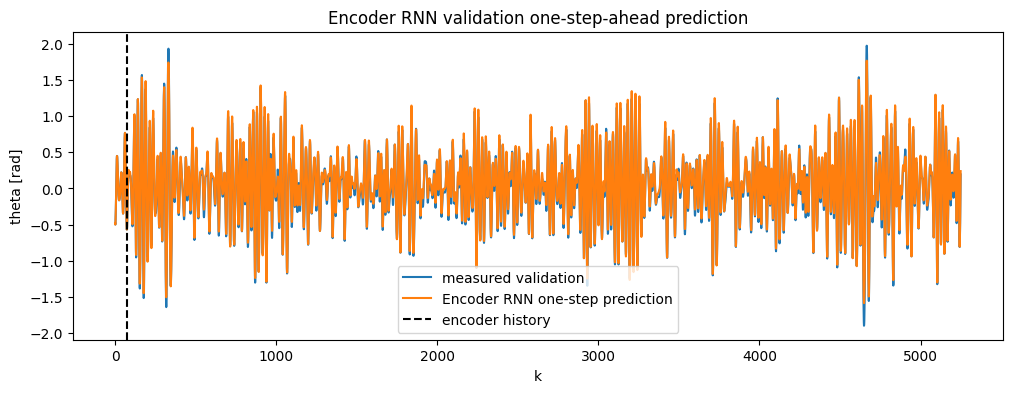

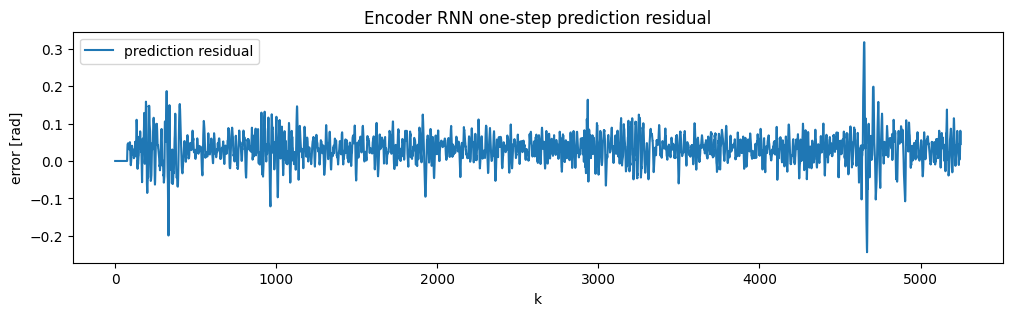

In [46]:
plt.figure(figsize=(12, 4))
plt.plot(th_val_true_encoder_rnn, label="measured validation")
plt.plot(th_val_pred_encoder_rnn, label="Encoder RNN one-step prediction")
plt.axvline(skip, color="black", linestyle="--", label="encoder history")
plt.xlabel("k")
plt.ylabel("theta [rad]")
plt.title("Encoder RNN validation one-step-ahead prediction")
plt.legend()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(th_val_pred_encoder_rnn - th_val_true_encoder_rnn, label="prediction residual")
plt.xlabel("k")
plt.ylabel("error [rad]")
plt.title("Encoder RNN one-step prediction residual")
plt.legend()
plt.show()

# Try with tanH

In [26]:
class simple_encoder_RNN_tanh(nn.Module):
    def __init__(self, hidden_size, n_encoder=20):
        super(simple_encoder_RNN_tanh, self).__init__()

        self.hidden_size = hidden_size
        self.input_size = 1
        self.output_size = 1
        self.n_encoder = n_encoder

        net = lambda n_in, n_out: nn.Sequential(
            nn.Linear(n_in, 40),
            nn.Tanh(),
            nn.Linear(40, n_out)
        ).double()

        self.h2h = net(self.input_size + hidden_size, self.hidden_size)
        self.h2o = net(self.input_size + hidden_size, self.output_size)
        self.encoder = net(n_encoder * 2, hidden_size)

    def forward(self, inputs, hist):
        hidden = self.encoder(hist)

        outputs = []

        for i in range(inputs.shape[1]):
            input_i = inputs[:, i]
            combined = torch.cat((hidden, input_i[:, None]), dim=1)

            outputs.append(self.h2o(combined)[:, 0])

            hidden = self.h2h(combined)

        return torch.stack(outputs, dim=1)

In [31]:
tanh_rnn_configs = [
    {"n_encode": 50, "hidden_size": 30, "epochs": 50, "lr": 1e-3}
]

tanh_rnn_results = []

best_tanh_rmse = np.inf
best_tanh_rnn = None
best_tanh_config = None
best_tanh_losses = None
best_tanh_n_encode = None
best_tanh_sim = None
best_tanh_true = None

nfuture_rnn = 100
batch_size = 64

for cfg in tanh_rnn_configs:
    print("\n====================================")
    print("Training Tanh Encoder RNN config:", cfg)
    print("====================================")

    n_encode = cfg["n_encode"]
    hidden_size = cfg["hidden_size"]
    epochs = cfg["epochs"]
    lr = cfg["lr"]

    convert = lambda x: [torch.tensor(xi, dtype=torch.float64) for xi in x]

    hist_train_rnn, U_train_rnn, Y_train_rnn = convert(
        make_OE_init_state_data(
            u_train_n,
            th_train_n,
            nf=nfuture_rnn,
            n_encode=n_encode
        )
    )

    hist_val_rnn, U_val_rnn, Y_val_rnn = convert(
        make_OE_init_state_data(
            u_val_n,
            th_val_n,
            nf=nfuture_rnn,
            n_encode=n_encode
        )
    )

    model_tanh_rnn = simple_encoder_RNN_tanh(
        hidden_size=hidden_size,
        n_encoder=n_encode
    )

    optimizer = torch.optim.Adam(model_tanh_rnn.parameters(), lr=lr)

    train_losses_tanh = []
    val_losses_tanh = []

    ids = np.arange(len(U_train_rnn), dtype=int)

    for epoch in range(epochs):
        np.random.shuffle(ids)

        model_tanh_rnn.train()

        for i in range(0, len(U_train_rnn), batch_size):
            ids_now = ids[i:i+batch_size]

            Uin = U_train_rnn[ids_now]
            histin = hist_train_rnn[ids_now]
            Y_real = Y_train_rnn[ids_now]

            Y_predict = model_tanh_rnn(inputs=Uin, hist=histin)

            loss = torch.mean((Y_real - Y_predict)**2)

            optimizer.zero_grad()
            loss.backward()

            # Gradient clipping for recurrent training stability
            torch.nn.utils.clip_grad_norm_(model_tanh_rnn.parameters(), max_norm=1.0)

            optimizer.step()

        model_tanh_rnn.eval()
        with torch.no_grad():
            Y_val_pred = model_tanh_rnn(inputs=U_val_rnn, hist=hist_val_rnn)
            Y_train_pred = model_tanh_rnn(inputs=U_train_rnn, hist=hist_train_rnn)

            loss_val = torch.mean((Y_val_pred - Y_val_rnn)**2)**0.5
            loss_train = torch.mean((Y_train_pred - Y_train_rnn)**2)**0.5

        train_losses_tanh.append(loss_train.item())
        val_losses_tanh.append(loss_val.item())

        print(f"epoch={epoch}, Validation Loss={loss_val.item():.2%}, Train Loss={loss_train.item():.2%}")

    th_val_sim_tanh, th_val_true_tanh = simulate_encoder_rnn_full(
        model_tanh_rnn,
        u_val_n,
        th_val_n,
        n_encode,
        th_mean,
        th_std
    )

    skip = n_encode

    rms_tanh = np.sqrt(
        np.mean((th_val_sim_tanh[skip:] - th_val_true_tanh[skip:])**2)
    )
    rms_deg_tanh = rms_tanh / (2*np.pi) * 360
    nrms_tanh = rms_tanh / np.std(th_val_true_tanh[skip:])

    print("Tanh Encoder RNN full validation simulation RMS:", rms_tanh, "rad")
    print("Tanh Encoder RNN full validation simulation RMS:", rms_deg_tanh, "deg")
    print("Tanh Encoder RNN full validation simulation NRMS:", nrms_tanh * 100, "%")

    result = {
        "activation": "tanh",
        "n_encode": n_encode,
        "hidden_size": hidden_size,
        "epochs": epochs,
        "lr": lr,
        "rmse_rad": rms_tanh,
        "rmse_deg": rms_deg_tanh,
        "nrms_percent": nrms_tanh * 100,
        "best_window_val_loss": np.min(val_losses_tanh),
        "best_epoch": int(np.argmin(val_losses_tanh))
    }

    tanh_rnn_results.append(result)

    if rms_tanh < best_tanh_rmse:
        best_tanh_rmse = rms_tanh
        best_tanh_rnn = copy.deepcopy(model_tanh_rnn)
        best_tanh_config = copy.deepcopy(cfg)
        best_tanh_losses = (train_losses_tanh, val_losses_tanh)
        best_tanh_n_encode = n_encode
        best_tanh_sim = th_val_sim_tanh
        best_tanh_true = th_val_true_tanh

tanh_rnn_results_df = pd.DataFrame(tanh_rnn_results)
tanh_rnn_results_df.sort_values("rmse_rad")


Training Tanh Encoder RNN config: {'n_encode': 50, 'hidden_size': 30, 'epochs': 50, 'lr': 0.001}
epoch=0, Validation Loss=38.18%, Train Loss=30.29%
epoch=1, Validation Loss=37.37%, Train Loss=29.16%
epoch=2, Validation Loss=35.83%, Train Loss=29.09%
epoch=3, Validation Loss=30.67%, Train Loss=24.74%
epoch=4, Validation Loss=24.87%, Train Loss=16.81%
epoch=5, Validation Loss=20.02%, Train Loss=11.43%
epoch=6, Validation Loss=37.39%, Train Loss=33.44%
epoch=7, Validation Loss=22.00%, Train Loss=14.69%
epoch=8, Validation Loss=19.45%, Train Loss=13.01%
epoch=9, Validation Loss=24.36%, Train Loss=17.21%
epoch=10, Validation Loss=20.65%, Train Loss=13.21%
epoch=11, Validation Loss=22.59%, Train Loss=18.46%
epoch=12, Validation Loss=31.55%, Train Loss=26.47%
epoch=13, Validation Loss=20.20%, Train Loss=14.46%
epoch=14, Validation Loss=21.93%, Train Loss=16.39%
epoch=15, Validation Loss=23.93%, Train Loss=17.06%
epoch=16, Validation Loss=26.80%, Train Loss=21.93%
epoch=17, Validation Loss=20

,activation,n_encode,hidden_size,epochs,lr,rmse_rad,rmse_deg,nrms_percent,best_window_val_loss,best_epoch
0,tanh,50,30,50,0.001,0.157087,9.000425,31.803676,0.13975,45


In [32]:
print("Best Tanh Encoder RNN configuration:")
print(best_tanh_config)

print("\nBest Tanh Encoder RNN full validation RMSE:", best_tanh_rmse, "rad")

tanh_rnn_results_df.sort_values("rmse_rad")

Best Tanh Encoder RNN configuration:
{'n_encode': 50, 'hidden_size': 30, 'epochs': 50, 'lr': 0.001}

Best Tanh Encoder RNN full validation RMSE: 0.15708705423740071 rad


,activation,n_encode,hidden_size,epochs,lr,rmse_rad,rmse_deg,nrms_percent,best_window_val_loss,best_epoch
0,tanh,50,30,50,0.001,0.157087,9.000425,31.803676,0.13975,45


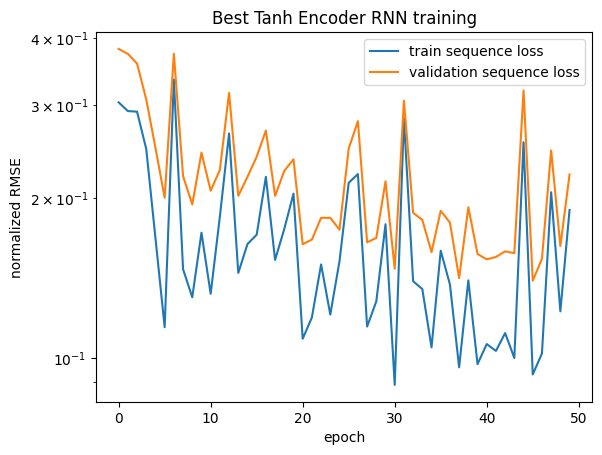

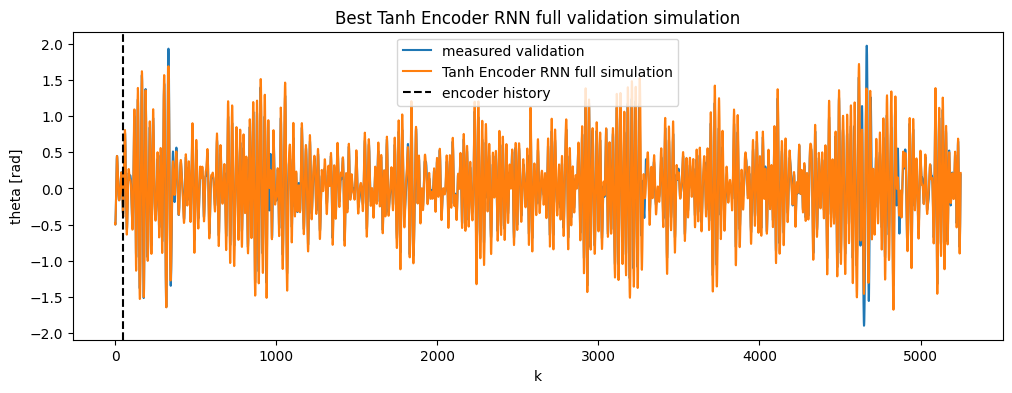

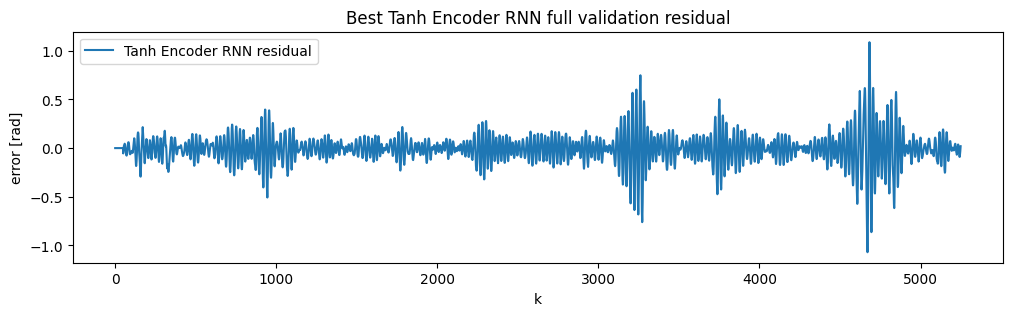

In [34]:
train_losses_tanh, val_losses_tanh = best_tanh_losses

plt.figure()
plt.plot(train_losses_tanh, label="train sequence loss")
plt.plot(val_losses_tanh, label="validation sequence loss")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("normalized RMSE")
plt.title("Best Tanh Encoder RNN training")
plt.legend()
plt.show()

skip = best_tanh_n_encode

plt.figure(figsize=(12, 4))
plt.plot(best_tanh_true, label="measured validation")
plt.plot(best_tanh_sim, label="Tanh Encoder RNN full simulation")
plt.axvline(skip, color="black", linestyle="--", label="encoder history")
plt.xlabel("k")
plt.ylabel("theta [rad]")
plt.title("Best Tanh Encoder RNN full validation simulation")
plt.legend()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(best_tanh_sim - best_tanh_true, label="Tanh Encoder RNN residual")
plt.xlabel("k")
plt.ylabel("error [rad]")
plt.title("Best Tanh Encoder RNN full validation residual")
plt.legend()
plt.show()

In [36]:
final_tanh_rnn = best_tanh_rnn
final_tanh_n_encode = best_tanh_n_encode

th_val_pred_tanh_rnn, th_val_true_tanh_rnn = one_step_prediction_encoder_rnn(
    final_tanh_rnn,
    u_val_n,
    th_val_n,
    final_tanh_n_encode,
    th_mean,
    th_std
)

skip = final_tanh_n_encode

rms_pred_tanh_rnn = np.sqrt(
    np.mean((th_val_pred_tanh_rnn[skip:] - th_val_true_tanh_rnn[skip:])**2)
)

rms_deg_pred_tanh_rnn = rms_pred_tanh_rnn / (2*np.pi) * 360
nrms_pred_tanh_rnn = rms_pred_tanh_rnn / np.std(th_val_true_tanh_rnn[skip:])

print("Tanh Encoder RNN one-step prediction RMS:", rms_pred_tanh_rnn, "rad")
print("Tanh Encoder RNN one-step prediction RMS:", rms_deg_pred_tanh_rnn, "deg")
print("Tanh Encoder RNN one-step prediction NRMS:", nrms_pred_tanh_rnn * 100, "%")

Tanh Encoder RNN one-step prediction RMS: 0.07410309299150744 rad
Tanh Encoder RNN one-step prediction RMS: 4.245794477278847 deg
Tanh Encoder RNN one-step prediction NRMS: 15.002832332092975 %


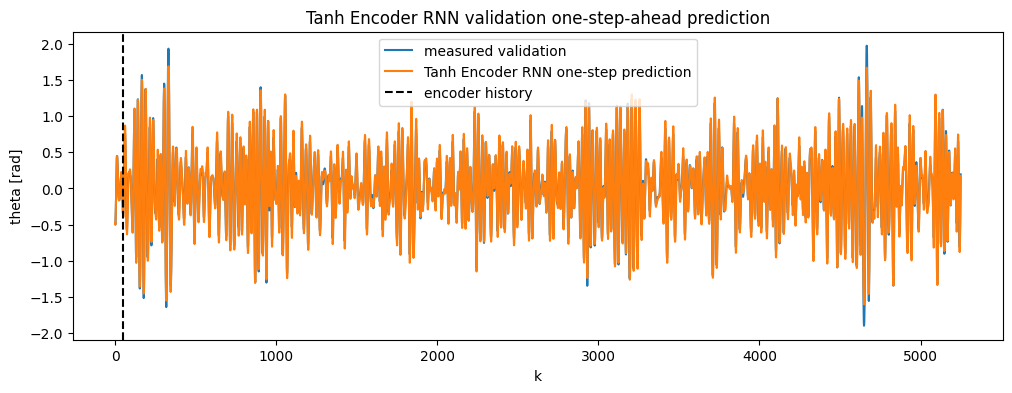

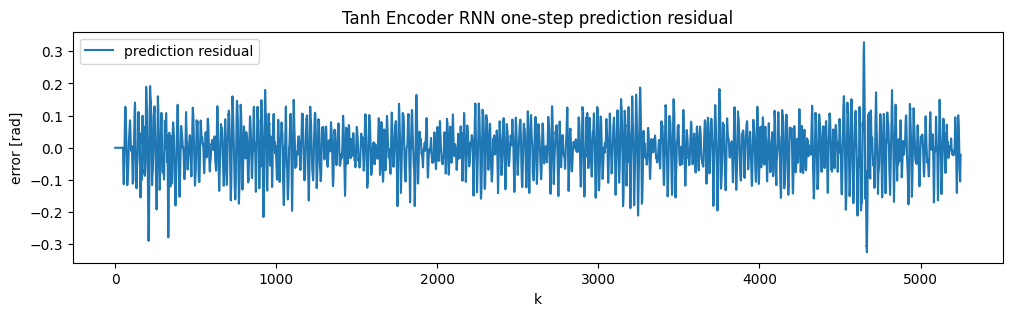

In [37]:
plt.figure(figsize=(12, 4))
plt.plot(th_val_true_tanh_rnn, label="measured validation")
plt.plot(th_val_pred_tanh_rnn, label="Tanh Encoder RNN one-step prediction")
plt.axvline(skip, color="black", linestyle="--", label="encoder history")
plt.xlabel("k")
plt.ylabel("theta [rad]")
plt.title("Tanh Encoder RNN validation one-step-ahead prediction")
plt.legend()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(th_val_pred_tanh_rnn - th_val_true_tanh_rnn, label="prediction residual")
plt.xlabel("k")
plt.ylabel("error [rad]")
plt.title("Tanh Encoder RNN one-step prediction residual")
plt.legend()
plt.show()